In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_funding_rounds.csv')
df['Date'] = pd.to_datetime(df['Date'])

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(df.shape)
df.head()

(1100, 12)


,Startup,Industry,SubVertical,City,Investors,InvestmentType,InvestmentAmount_USD,Date,Year,Quarter,Log_Amount,Stage_Group
0,Housejoy,EdTech,K12,Mumbai,Lightspeed India,Seed,199000,2023-04-19,2023,2,5.298853,Early
1,Groww,Media,Streaming,Bengaluru,IFC,Seed,1668000,2025-01-28,2025,1,6.222196,Early
2,Groww,Mobility,Ride Sharing,Hyderabad,"Nexus Venture Partners, Peak XV",Series B,38052000,2021-03-14,2021,1,7.580377,Growth
3,FarmBox,Consumer Electronics,Wearables,Gurugram,"Kalaari Capital, Y Combinator",Seed,455000,2023-09-11,2023,3,5.658011,Early
4,Udaan,RealEstate,Rental Tech,Mumbai,Bessemer Venture Partners,Seed,89000,2024-01-31,2024,1,4.949390,Early


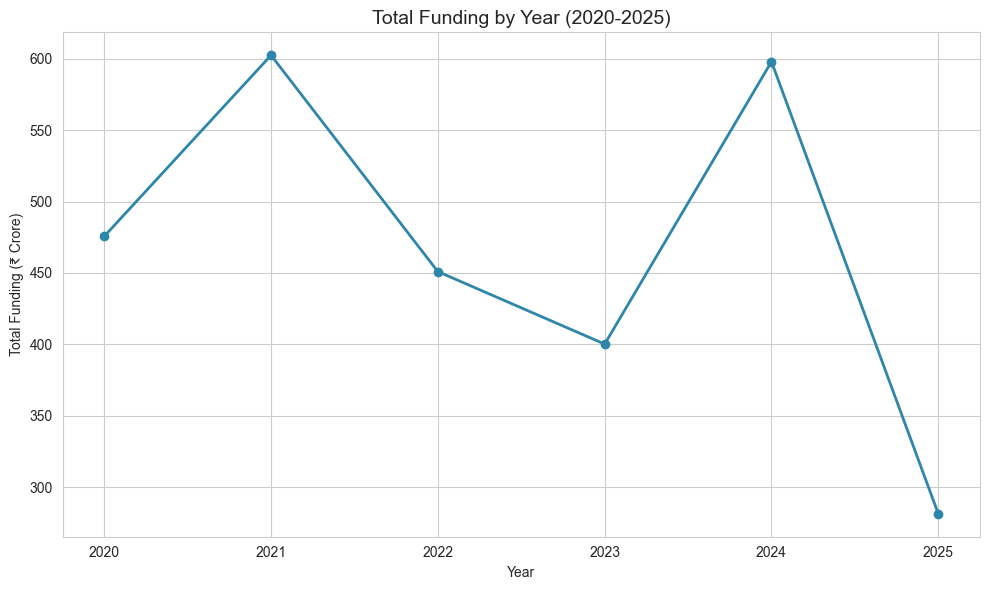

In [7]:
yearly = df.groupby('Year')['InvestmentAmount_USD'].sum() / 1e7  # convert to crores

plt.figure()
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2, color='#2E86AB')
plt.title('Total Funding by Year (2020-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Funding (₹ Crore)')
plt.xticks(yearly.index)
plt.tight_layout()
plt.savefig('chart1_yearly_trend.png', dpi=150)
plt.show()

C:\Users\ashif\AppData\Local\Temp\ipykernel_5708\2631932560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Stage_Group', y='Log_Amount', order=['Early', 'Growth', 'Late', 'Other'], palette='viridis')


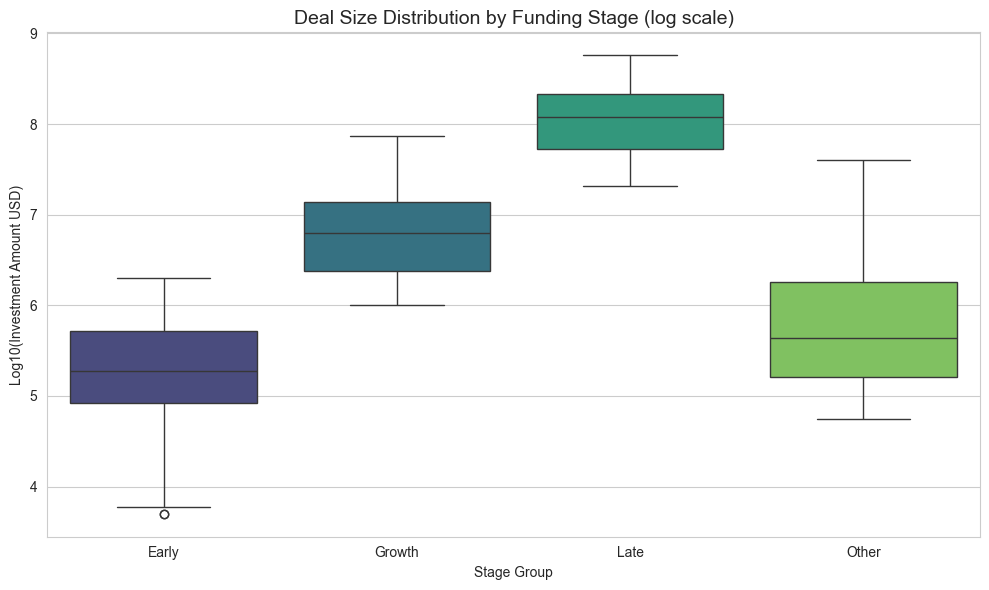

In [8]:
plt.figure()
sns.boxplot(data=df, x='Stage_Group', y='Log_Amount', order=['Early', 'Growth', 'Late', 'Other'], palette='viridis')
plt.title('Deal Size Distribution by Funding Stage (log scale)', fontsize=14)
plt.xlabel('Stage Group')
plt.ylabel('Log10(Investment Amount USD)')
plt.tight_layout()
plt.savefig('chart2_stage_boxplot.png', dpi=150)
plt.show()

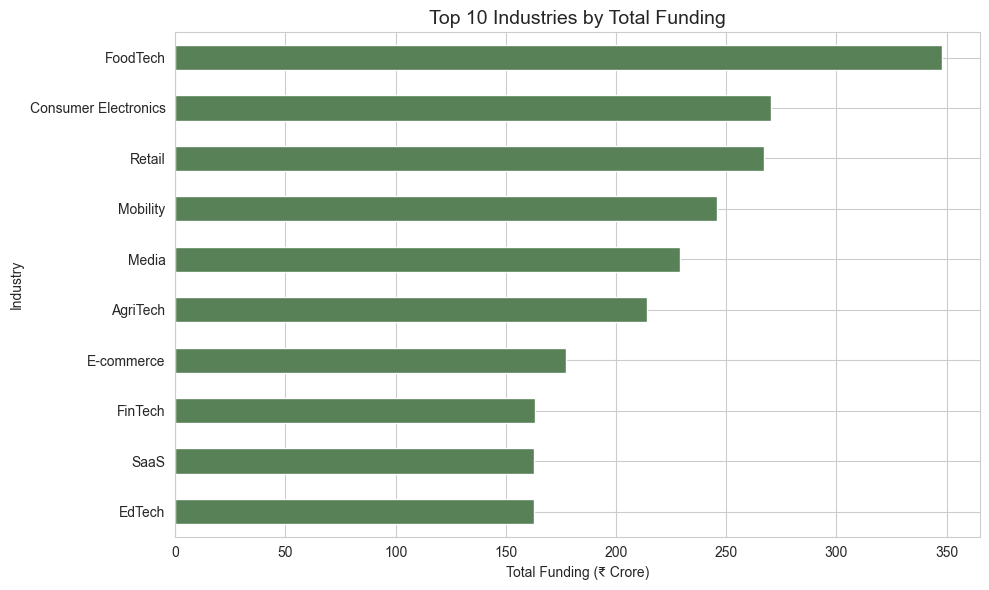

In [9]:
sector_totals = df.groupby('Industry')['InvestmentAmount_USD'].sum().sort_values(ascending=False).head(10) / 1e7

plt.figure()
sector_totals.plot(kind='barh', color='#588157')
plt.title('Top 10 Industries by Total Funding', fontsize=14)
plt.xlabel('Total Funding (₹ Crore)')
plt.ylabel('Industry')
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.savefig('chart3_sector_totals.png', dpi=150)
plt.show()

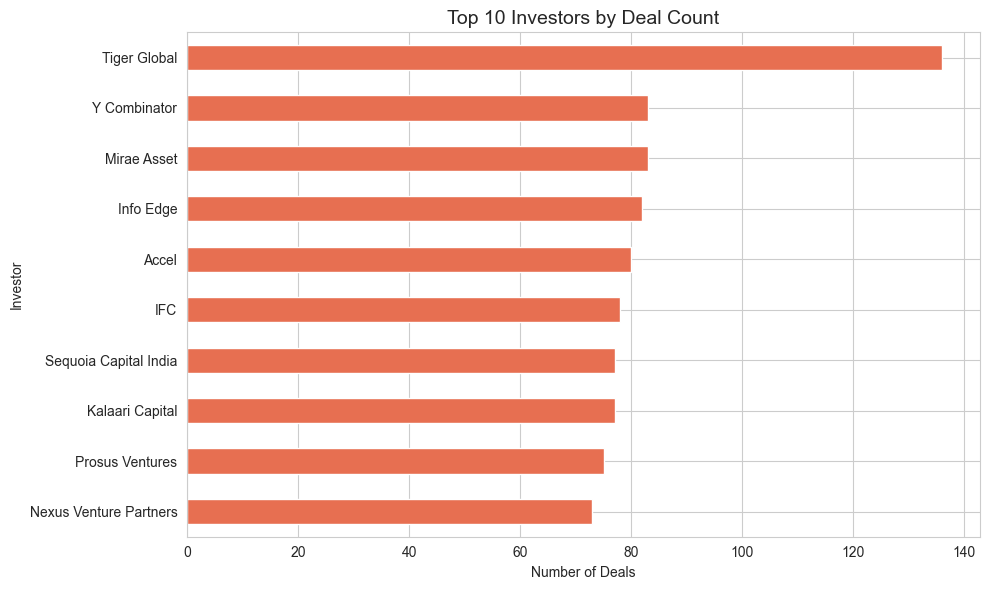

In [10]:
df_investors = pd.read_csv('cleaned_investors_exploded.csv')

top_investors = df_investors['Investors'].value_counts().head(10)

plt.figure()
top_investors.plot(kind='barh', color='#E76F51')
plt.title('Top 10 Investors by Deal Count', fontsize=14)
plt.xlabel('Number of Deals')
plt.ylabel('Investor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart4_top_investors.png', dpi=150)
plt.show()

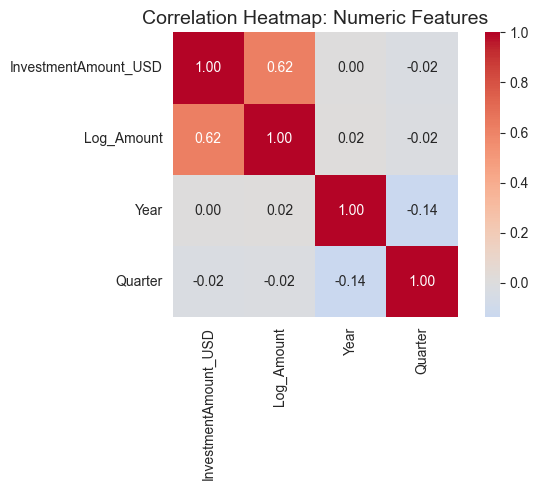

In [11]:
numeric_cols = df[['InvestmentAmount_USD', 'Log_Amount', 'Year', 'Quarter']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap: Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150)
plt.show()

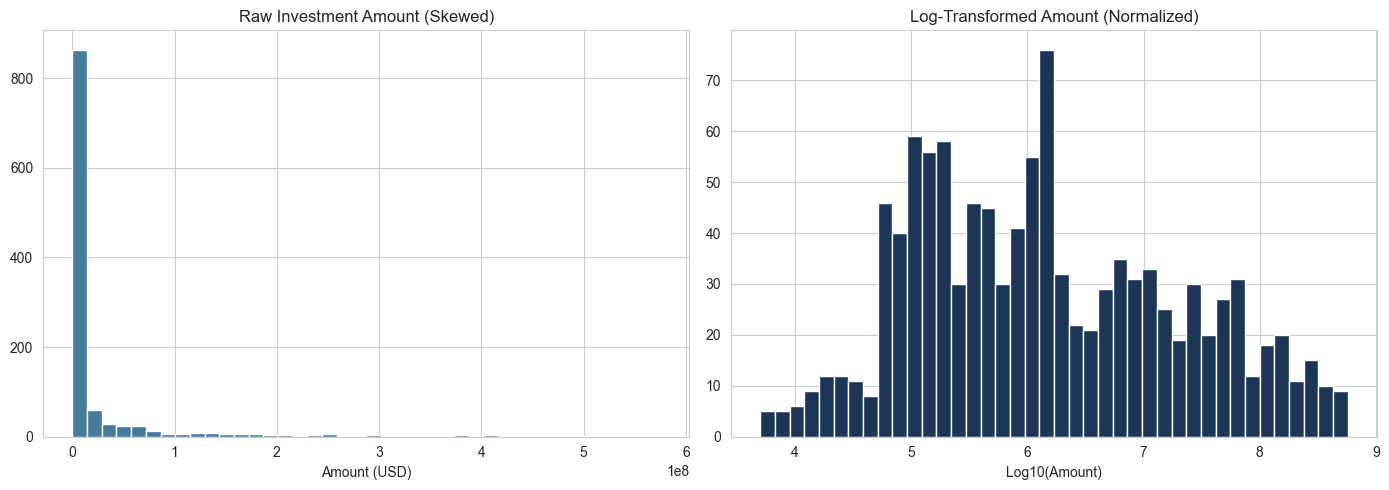

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['InvestmentAmount_USD'], bins=40, color='#457B9D', edgecolor='white')
axes[0].set_title('Raw Investment Amount (Skewed)')
axes[0].set_xlabel('Amount (USD)')

axes[1].hist(df['Log_Amount'], bins=40, color='#1D3557', edgecolor='white')
axes[1].set_title('Log-Transformed Amount (Normalized)')
axes[1].set_xlabel('Log10(Amount)')

plt.tight_layout()
plt.savefig('chart6_skew_comparison.png', dpi=150)
plt.show()